---
title: "Berlin Kitas"
description: "How many kitas?"
author: "Mads Chr. Hansen"
date: "2025-03-22"
categories: [Numpyro]
image: "https://images.unsplash.com/photo-1587330979470-3595ac045ab0?q=80&w=3270&auto=format&fit=crop&ixlib=rb-4.0.3&ixid=M3wxMjA3fDB8MHxwaG90by1wYWdlfHx8fGVufDB8fHx8fA%3D%3D"
format:
  html:
    code-fold: true
    code-tools: true
toc: true
---

In [13]:
import arviz as az
import geopandas as gpd
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import numpyro
import numpyro.distributions as dist
import pandas as pd
import seaborn as sns
from jax import random
from jaxlib.xla_extension import ArrayImpl
from numpyro.diagnostics import hpdi, print_summary
from numpyro.infer import MCMC, NUTS, SVI, Predictive, Trace_ELBO, init_to_value
from numpyro.infer.autoguide import AutoNormal
from sklearn.preprocessing import LabelEncoder

plt.style.use("ggplot")
plt.rcParams["figure.figsize"] = [10, 6]
plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.facecolor"] = "white"

numpyro.set_host_device_count(n=4)

rng_key = random.PRNGKey(seed=0)

%load_ext autoreload
%autoreload 2
%config InlineBackend.figure_format = "retina"

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
data_path = "https://raw.githubusercontent.com/juanitorduz/website_projects/master/data/kitas_data.geojson"

plz_df: gpd.GeoDataFrame = gpd.read_file(data_path)

plz_df = plz_df.sort_values(by=["district", "plz"])

plz_df.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 214 entries, 46 to 213
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   plz                   214 non-null    object  
 1   einwohner             214 non-null    int32   
 2   district              214 non-null    object  
 3   num_kitas_plz         214 non-null    int32   
 4   spots_plz             214 non-null    float64 
 5   num_kitas_plz_pc      214 non-null    float64 
 6   num_kitas_plz_pc_log  214 non-null    float64 
 7   geometry              214 non-null    geometry
dtypes: float64(3), geometry(1), int32(2), object(2)
memory usage: 13.4+ KB


In [17]:
plz_df

,plz,einwohner,district,num_kitas_plz,spots_plz,num_kitas_plz_pc,num_kitas_plz_pc_log,geometry,area
46,10585,12688,Charlottenburg-Wilmersdorf,12,609.0,0.000946,-6.963505,"POLYGON ((13.29676 52.51857, 13.29682 52.51858...",2.079206e+06
49,10587,11069,Charlottenburg-Wilmersdorf,14,661.0,0.001265,-6.672846,"POLYGON ((13.29967 52.52112, 13.30012 52.52188...",3.932108e+06
40,10589,12958,Charlottenburg-Wilmersdorf,16,749.0,0.001235,-6.696880,"POLYGON ((13.29272 52.53167, 13.29369 52.53236...",4.907840e+06
61,10623,5680,Charlottenburg-Wilmersdorf,5,354.0,0.000880,-7.035269,"POLYGON ((13.31776 52.50592, 13.31781 52.50626...",3.118309e+06
62,10623,5680,Charlottenburg-Wilmersdorf,5,354.0,0.000880,-7.035269,"POLYGON ((13.31837 52.50216, 13.31841 52.50239...",2.289196e+04
...,...,...,...,...,...,...,...,...,...
203,12557,21494,Treptow-Köpenick,12,888.0,0.000558,-7.490622,"POLYGON ((13.55915 52.44178, 13.5604 52.44222,...",2.168302e+07
209,12559,17643,Treptow-Köpenick,7,707.0,0.000397,-7.832184,"POLYGON ((13.58139 52.44185, 13.58151 52.44239...",7.559181e+03
210,12559,17643,Treptow-Köpenick,7,707.0,0.000397,-7.832184,"POLYGON ((13.58177 52.44236, 13.58248 52.44299...",1.006938e+08
212,12587,17717,Treptow-Köpenick,13,959.0,0.000734,-7.217331,"POLYGON ((13.59408 52.45418, 13.5943 52.45452,...",4.102289e+07


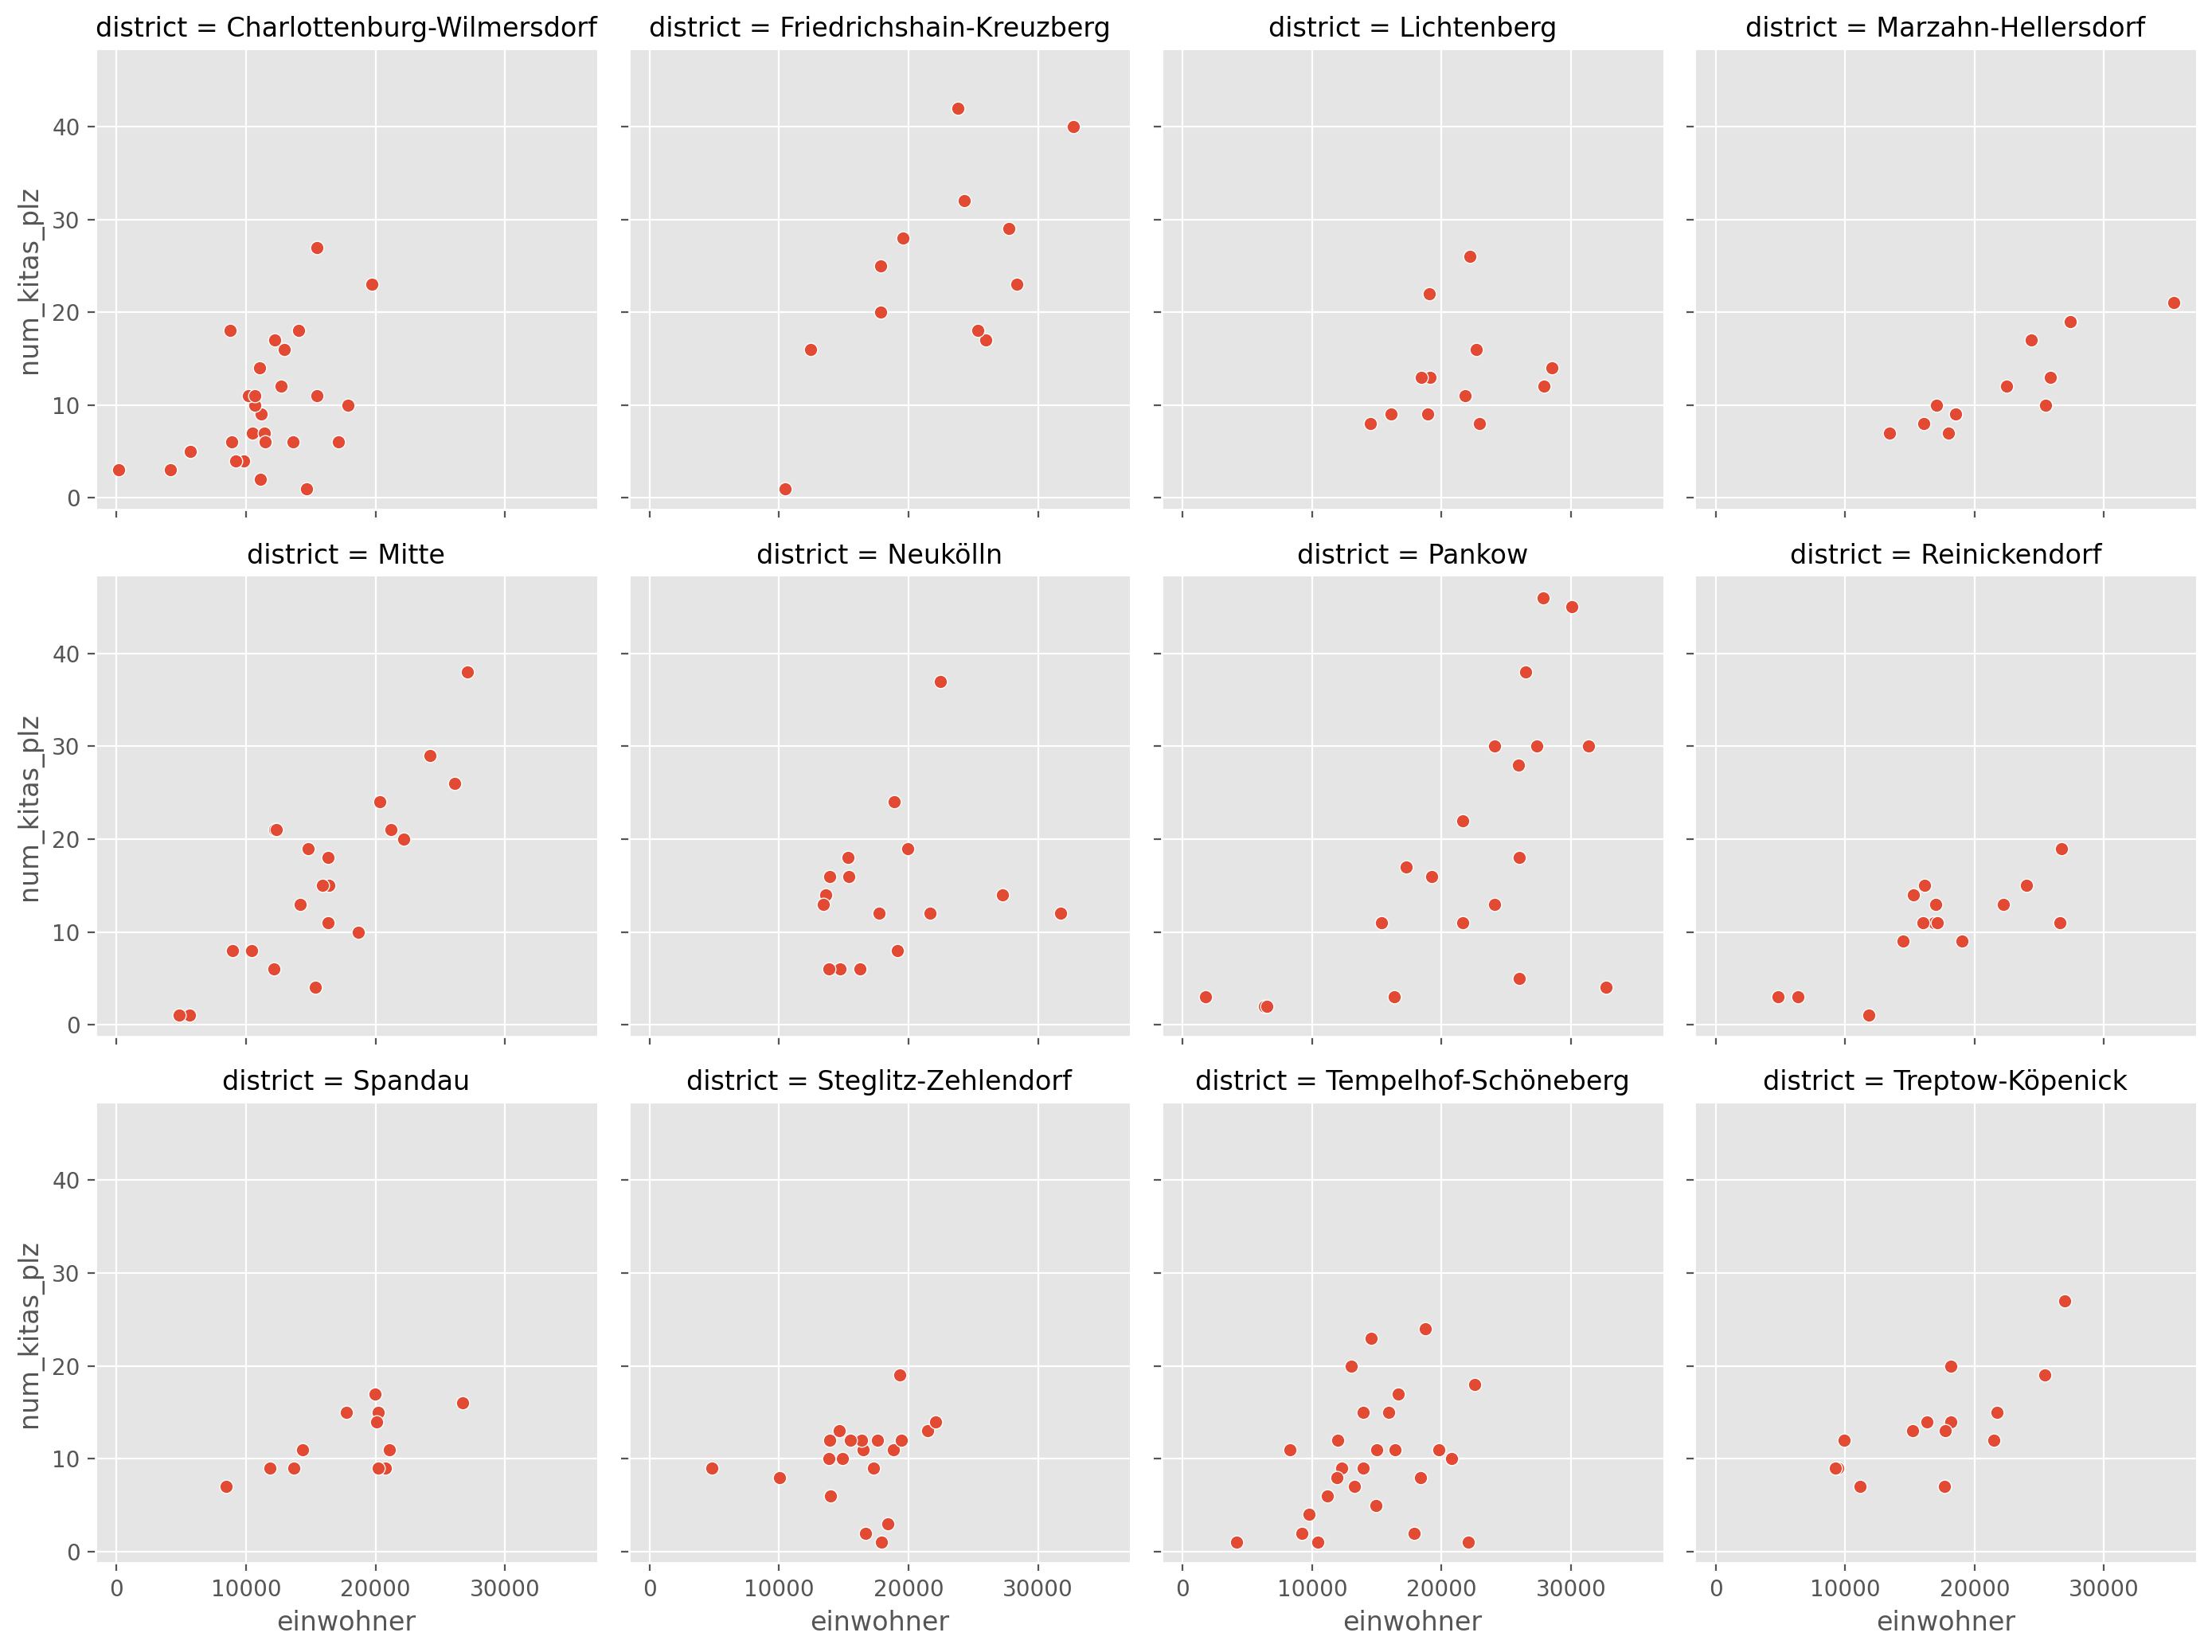

In [4]:
g = sns.relplot(
    data=plz_df,
    x="einwohner",
    y="num_kitas_plz",
    col="district",
    col_wrap=4,
    height=3.5,
    aspect=1,
)

In [5]:
num_kitas_plz = jnp.array(plz_df["num_kitas_plz"].to_numpy())

# https://geopandas.org/en/stable/docs/user_guide/projections.html
plz_df["area"] = plz_df["geometry"].to_crs("EPSG:3395").area
area_normalization = 1e8
area = jnp.array(plz_df["area"].to_numpy() / area_normalization)

einwohner_normalization = 1e4
einwohner = jnp.array(plz_df["einwohner"].to_numpy() / einwohner_normalization)

districts_encoder = LabelEncoder()
districts = districts_encoder.fit_transform(plz_df["district"])

In [8]:
def model(
    area: ArrayImpl,
    einwohner: ArrayImpl,
    districts: ArrayImpl,
    num_kitas_plz: ArrayImpl | None = None,
) -> None:
    """Hierarchical model for the number of kitas per plz as a function of the number
    of inhabitants (eihnwohner) and the district.

    Parameters
    ----------
    area : ArrayImpl
        Area of the plz.
    einwohner : ArrayImpl
        Number of inhabitants per plz.
    districts : ArrayImpl
        Districts of the plz.
    num_kitas_plz : ArrayImpl | None, optional
        Number of Kitas per plz, by default None
    """
    # Priors
    intercept_loc = numpyro.sample(
        name="intercept_loc", fn=dist.Normal(loc=0, scale=1.5)
    )
    intercept_scale = numpyro.sample(
        name="intercept_scale", fn=dist.HalfCauchy(scale=3)
    )
    slope_einwohner_loc = numpyro.sample(
        name="slope_einwohner_loc", fn=dist.Normal(loc=0, scale=1.5)
    )
    slope_einwohner_scale = numpyro.sample(
        name="slope_einwohner_scale", fn=dist.HalfCauchy(scale=3)
    )
    beta_area = numpyro.sample(name="beta_area", fn=dist.Normal(loc=0, scale=1.5))

    # We set the prior for the concentration parameter of the Negative Binomial
    # distribution on a transformed variable as suggested in
    # https://github.com/stan-dev/stan/wiki/Prior-Choice-Recommendations#story-when-the-generic-prior-fails-the-case-of-the-negative-binomial
    concentration_tilde = numpyro.sample(
        name="concentration_tilde", fn=dist.HalfCauchy(scale=3)
    )
    concentration = numpyro.deterministic(
        name="concentration", value=1 / jnp.square(concentration_tilde)
    )

    # Variables parametrization
    n_districts = np.unique(districts).size

    with numpyro.plate(name="districts", size=n_districts):
        intercept_district = numpyro.sample(
            name="intercept_district",
            fn=dist.Normal(loc=intercept_loc, scale=intercept_scale),
        )
        slope_einwohner = numpyro.sample(
            name="slope_einwohner",
            fn=dist.Normal(loc=slope_einwohner_loc, scale=slope_einwohner_scale),
        )

    log_mu = numpyro.deterministic(
        name="log_mu",
        value=intercept_district[districts]
        + slope_einwohner[districts] * einwohner
        + beta_area * area,
    )
    # We apply an exponential (link) function to make sure that mu is positive
    mu = numpyro.deterministic(name="mu", value=jnp.exp(log_mu))

    n_obs: int = einwohner.size

    # Likelihood
    with numpyro.plate(name="data", size=n_obs):
        numpyro.sample(
            name="obs",
            fn=dist.NegativeBinomial2(
                mean=mu,
                concentration=concentration,
            ),
            obs=num_kitas_plz,
        )

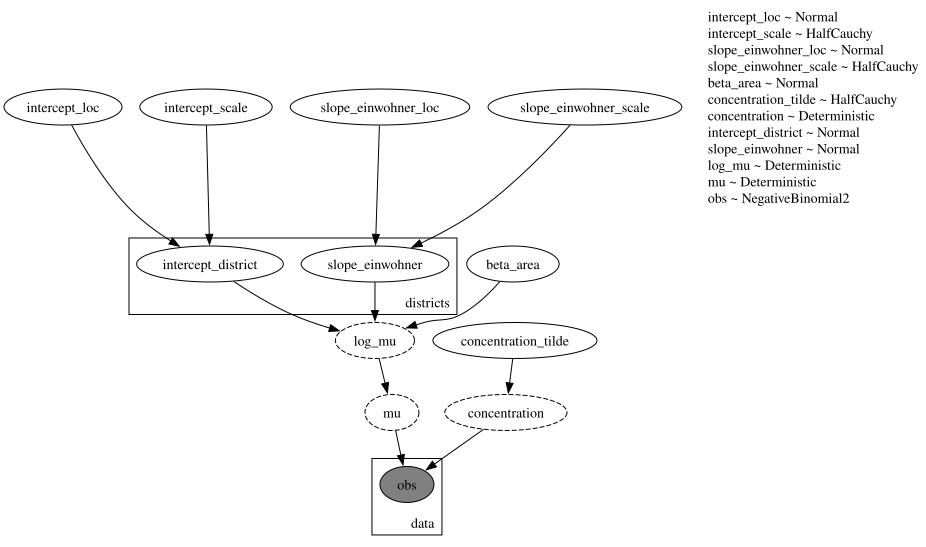

In [9]:
numpyro.render_model(
    model=model,
    model_args=(area, einwohner, districts, num_kitas_plz),
    render_distributions=True,
    render_params=True,
)

In [10]:
from numpyro.handlers import reparam
from numpyro.infer.reparam import LocScaleReparam

reparam_config = {
    "intercept_district": LocScaleReparam(centered=0),
    "slope_einwohner": LocScaleReparam(centered=0),
}

reparam_model = reparam(fn=model, config=reparam_config)

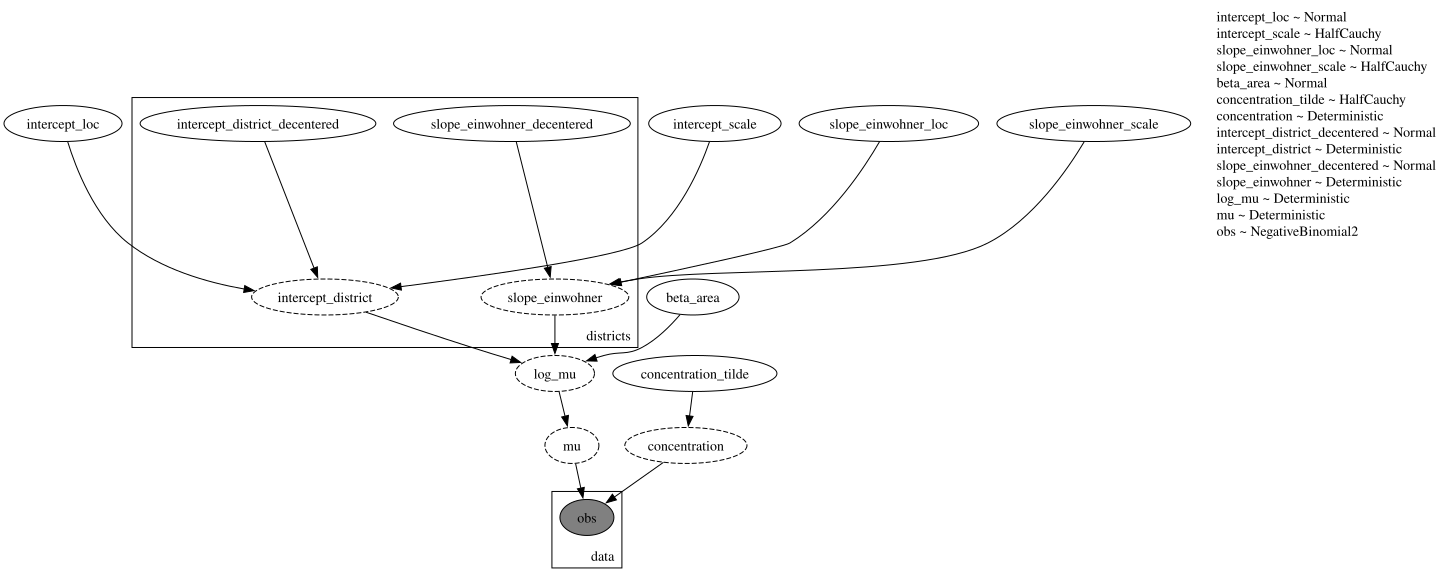

In [11]:
numpyro.render_model(
    model=reparam_model,
    model_args=(area, einwohner, districts, num_kitas_plz),
    render_distributions=True,
    render_params=True,
)

100%|██████████| 10000/10000 [00:04<00:00, 2216.77it/s, init loss: 2930.0234, avg. loss [9501-10000]: 710.8531]


Text(0.5, 1.0, 'ELBO loss')

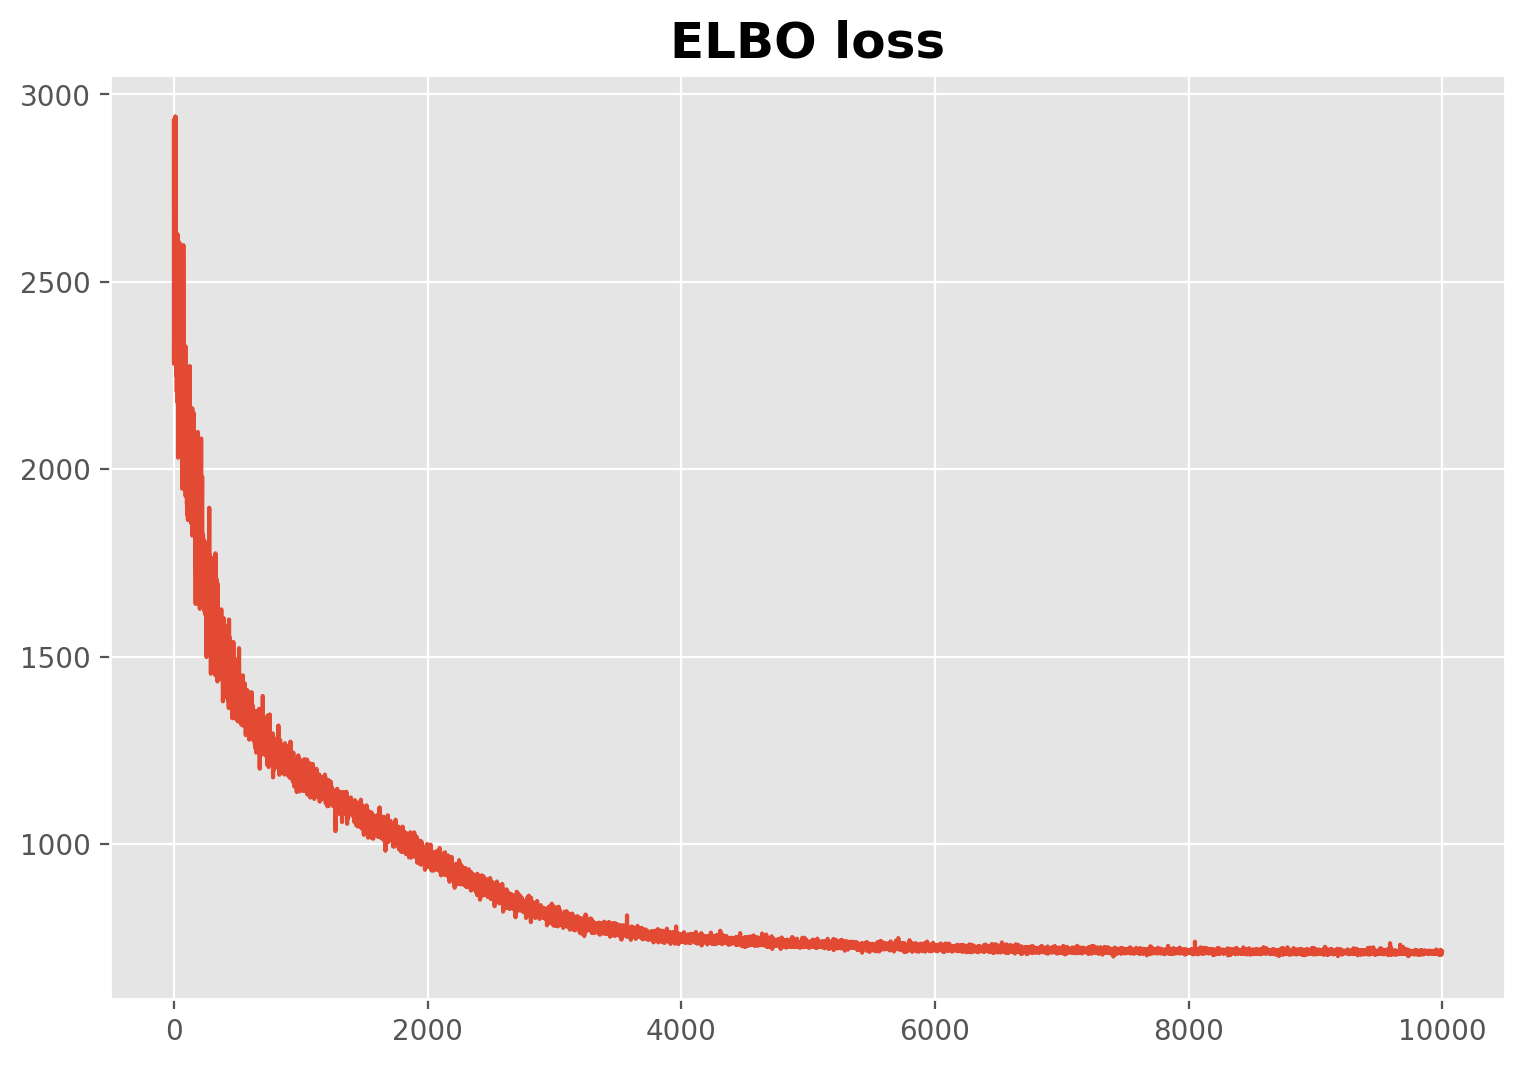

In [15]:
guide = AutoNormal(model)
optimizer = numpyro.optim.Adam(step_size=0.001)
svi = SVI(model, guide, optimizer, loss=Trace_ELBO())
num_steps = 10_000

rng_key, rng_subkey = random.split(key=rng_key)

svi_result = svi.run(rng_subkey, num_steps, area, einwohner, districts, num_kitas_plz)

fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(svi_result.losses)
ax.set_title("ELBO loss", fontsize=18, fontweight="bold")

In [16]:
samples = guide.sample_posterior(
    random.PRNGKey(1), svi_result.params, sample_shape=(1000,)
)
print_summary(samples, 0.89, False)


                             mean       std    median      5.5%     94.5%     n_eff     r_hat
              beta_area     -0.04      0.20     -0.03     -0.39      0.25   1066.02      1.00
          concentration      5.98      0.91      5.92      4.53      7.28    965.55      1.00
    concentration_tilde      0.41      0.03      0.41      0.37      0.46    968.31      1.00
  intercept_district[0]      1.31      0.07      1.31      1.20      1.43    968.21      1.00
  intercept_district[1]      1.34      0.09      1.33      1.19      1.49   1010.48      1.00
  intercept_district[2]      1.24      0.10      1.24      1.10      1.41   1088.58      1.00
  intercept_district[3]      1.19      0.10      1.19      1.01      1.33    964.89      1.00
  intercept_district[4]      1.34      0.09      1.34      1.19      1.46   1108.23      1.00
  intercept_district[5]      1.30      0.09      1.30      1.15      1.44   1053.48      1.00
  intercept_district[6]      1.23      0.08      1.24      

In [29]:
posterior_predictive = Predictive(
    model=model,
    guide=guide,
    params=svi_result.params,
    num_samples=5_000,
    return_sites=["obs"],
)

rng_key, rng_subkey = random.split(rng_key)
posterior_predictive_samples = posterior_predictive(
    rng_subkey,
    area,
    einwohner,
    districts,
)

In [ ]:
idata = az.from_dict(
    posterior_predictive={
        k: v[None, ...] for k, v in posterior_predictive_samples.items()
    },
)

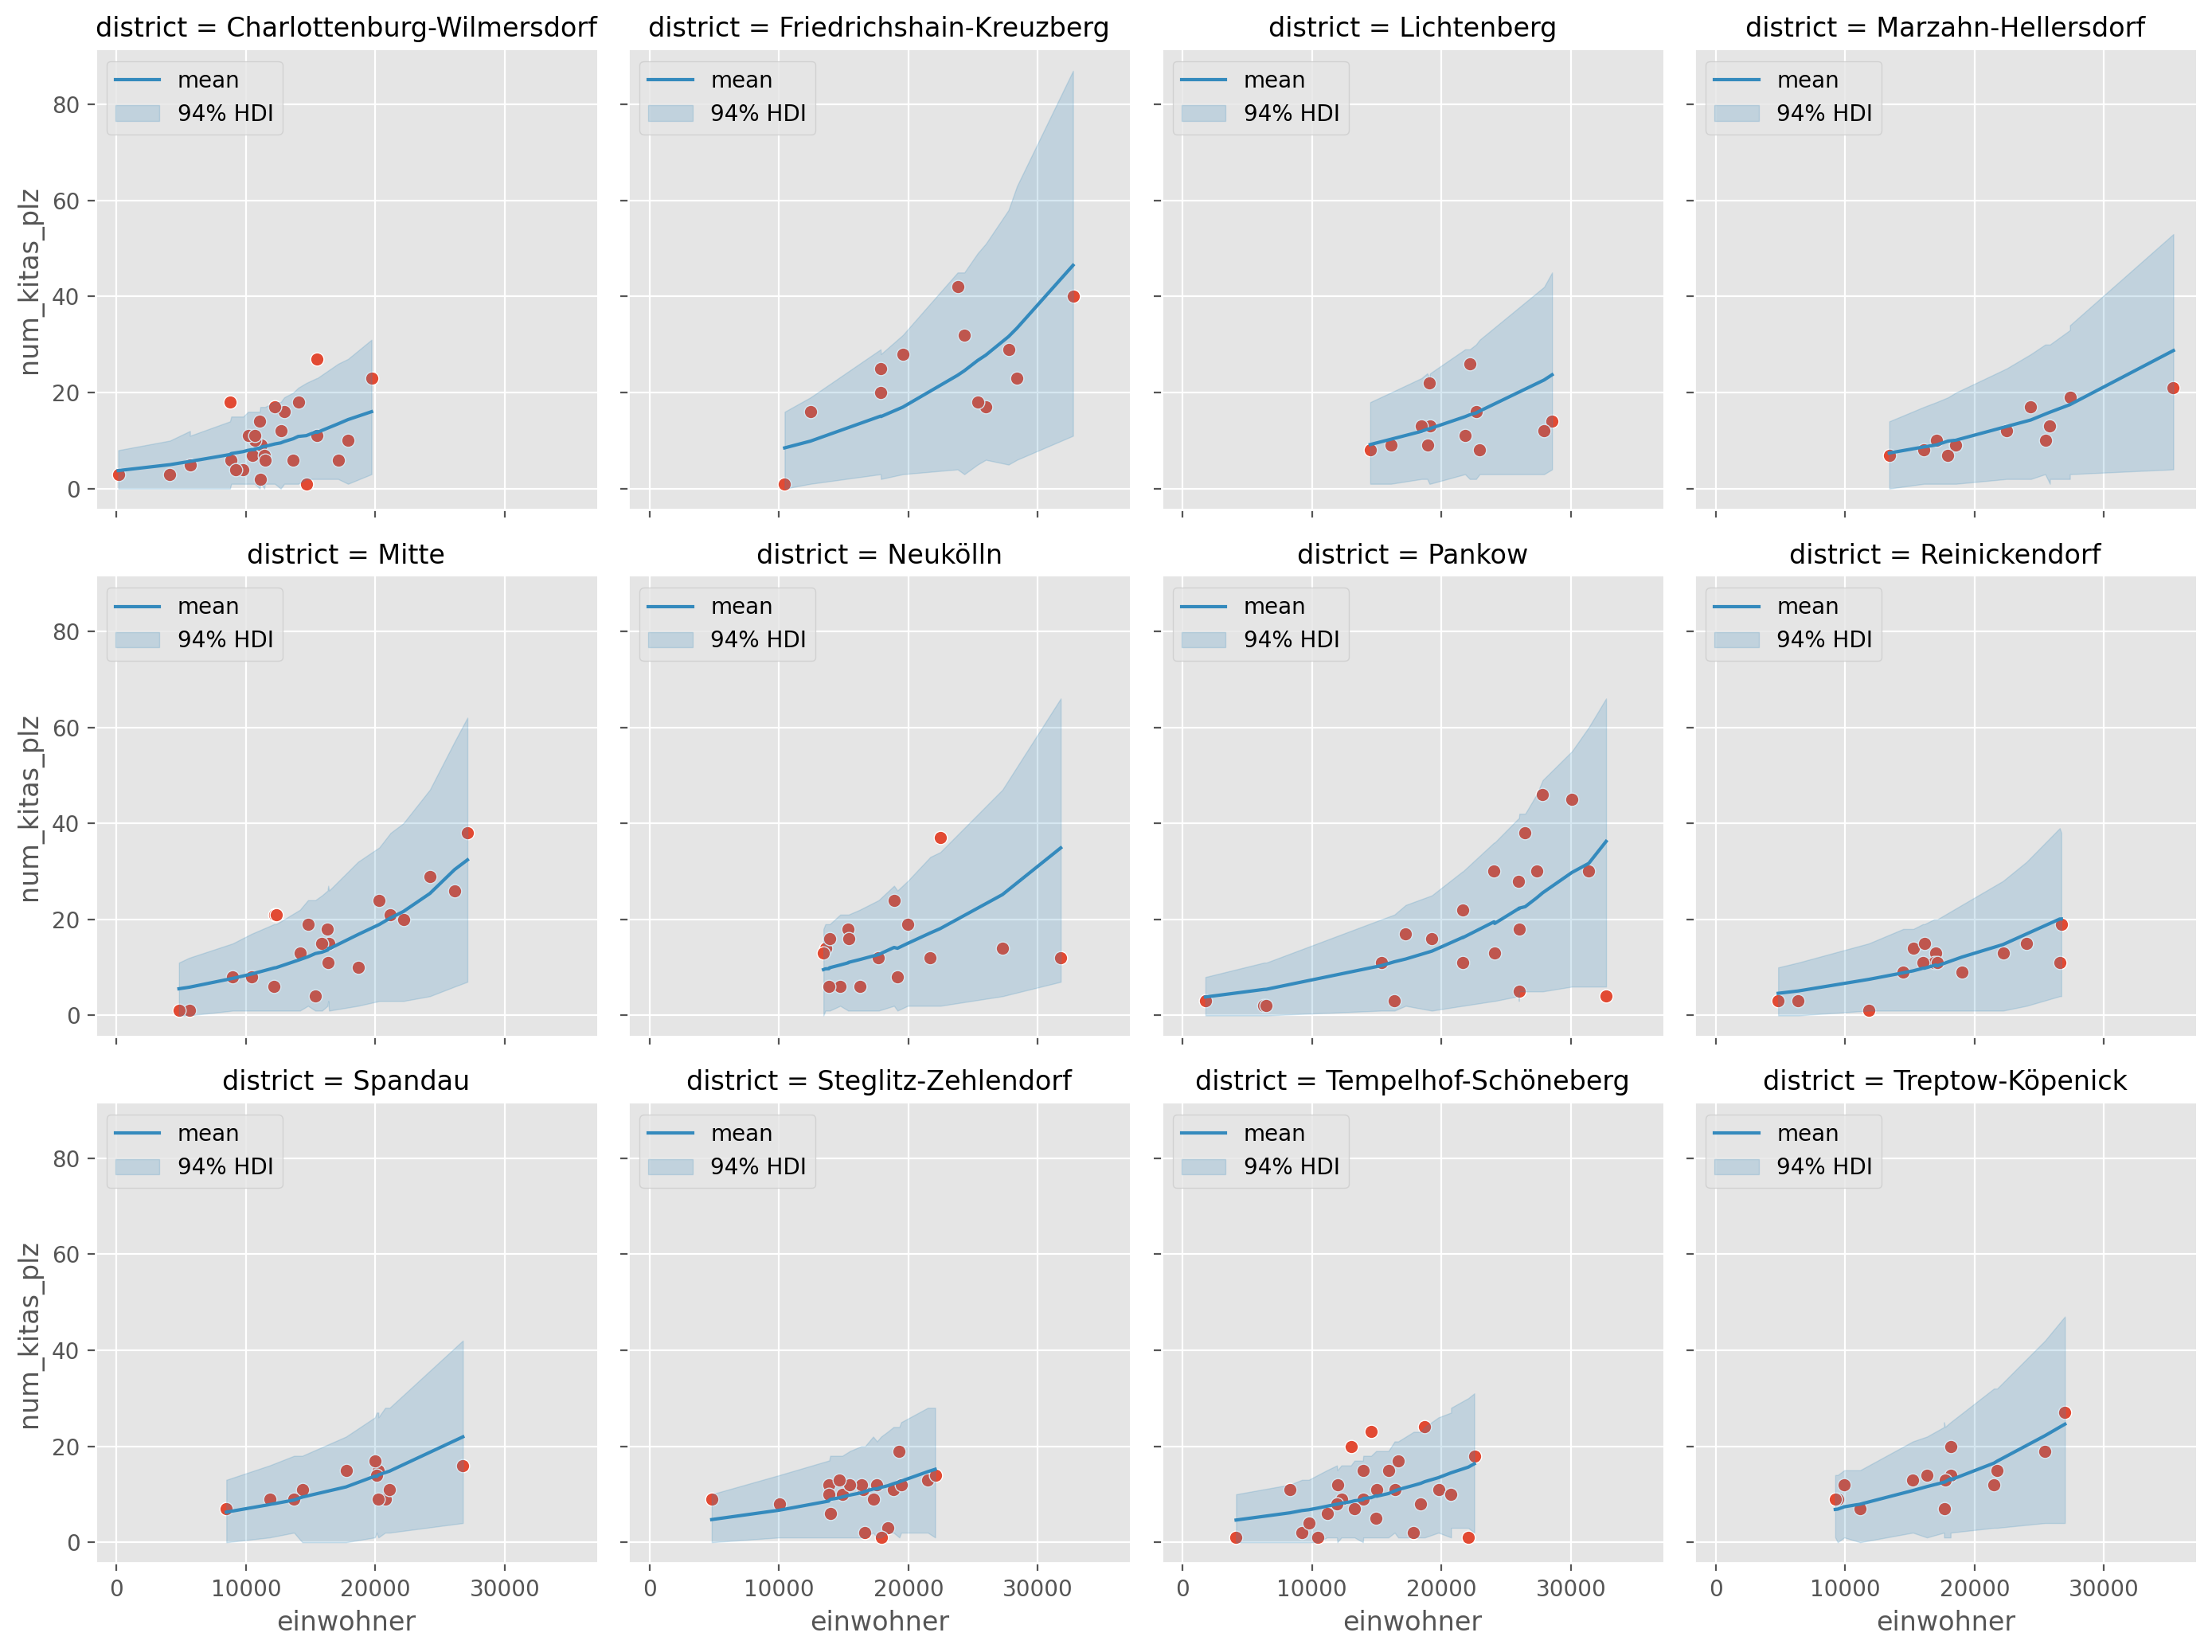

In [ ]:
plz_df["num_kitas_plz_pred_mean"] = idata["posterior_predictive"]["obs"].mean(
    axis=(0, 1)
)

posterior_predictive_hdi = az.hdi(
    ary=idata, group="posterior_predictive", hdi_prob=0.94
)["obs"]

plz_df["num_kitas_plz_pred_hdi_lower"] = posterior_predictive_hdi.sel(hdi="lower")
plz_df["num_kitas_plz_pred_hdi_higher"] = posterior_predictive_hdi.sel(hdi="higher")


g = sns.relplot(
    data=plz_df,
    x="einwohner",
    y="num_kitas_plz",
    color="C0",
    col="district",
    col_wrap=4,
    height=3.5,
    aspect=1,
)

for district, ax in g.axes_dict.items():
    mask = "district == @district"
    district_df = plz_df.query(mask).sort_values(by="einwohner")

    sns.lineplot(
        data=district_df,
        x="einwohner",
        y="num_kitas_plz_pred_mean",
        color="C1",
        label="mean",
        ax=ax,
    )

    ax.fill_between(
        x=district_df["einwohner"],
        y1=district_df["num_kitas_plz_pred_hdi_lower"],
        y2=district_df["num_kitas_plz_pred_hdi_higher"],
        color="C1",
        alpha=0.2,
        label="94% HDI",
    )
    ax.legend(loc="upper left")

[Text(0.5, 1.0, 'Posterior Predictive Mean - Slope Einwohner'),
 Text(0.5, 0, 'einwohner'),
 Text(0, 0.5, 'number of kitas')]

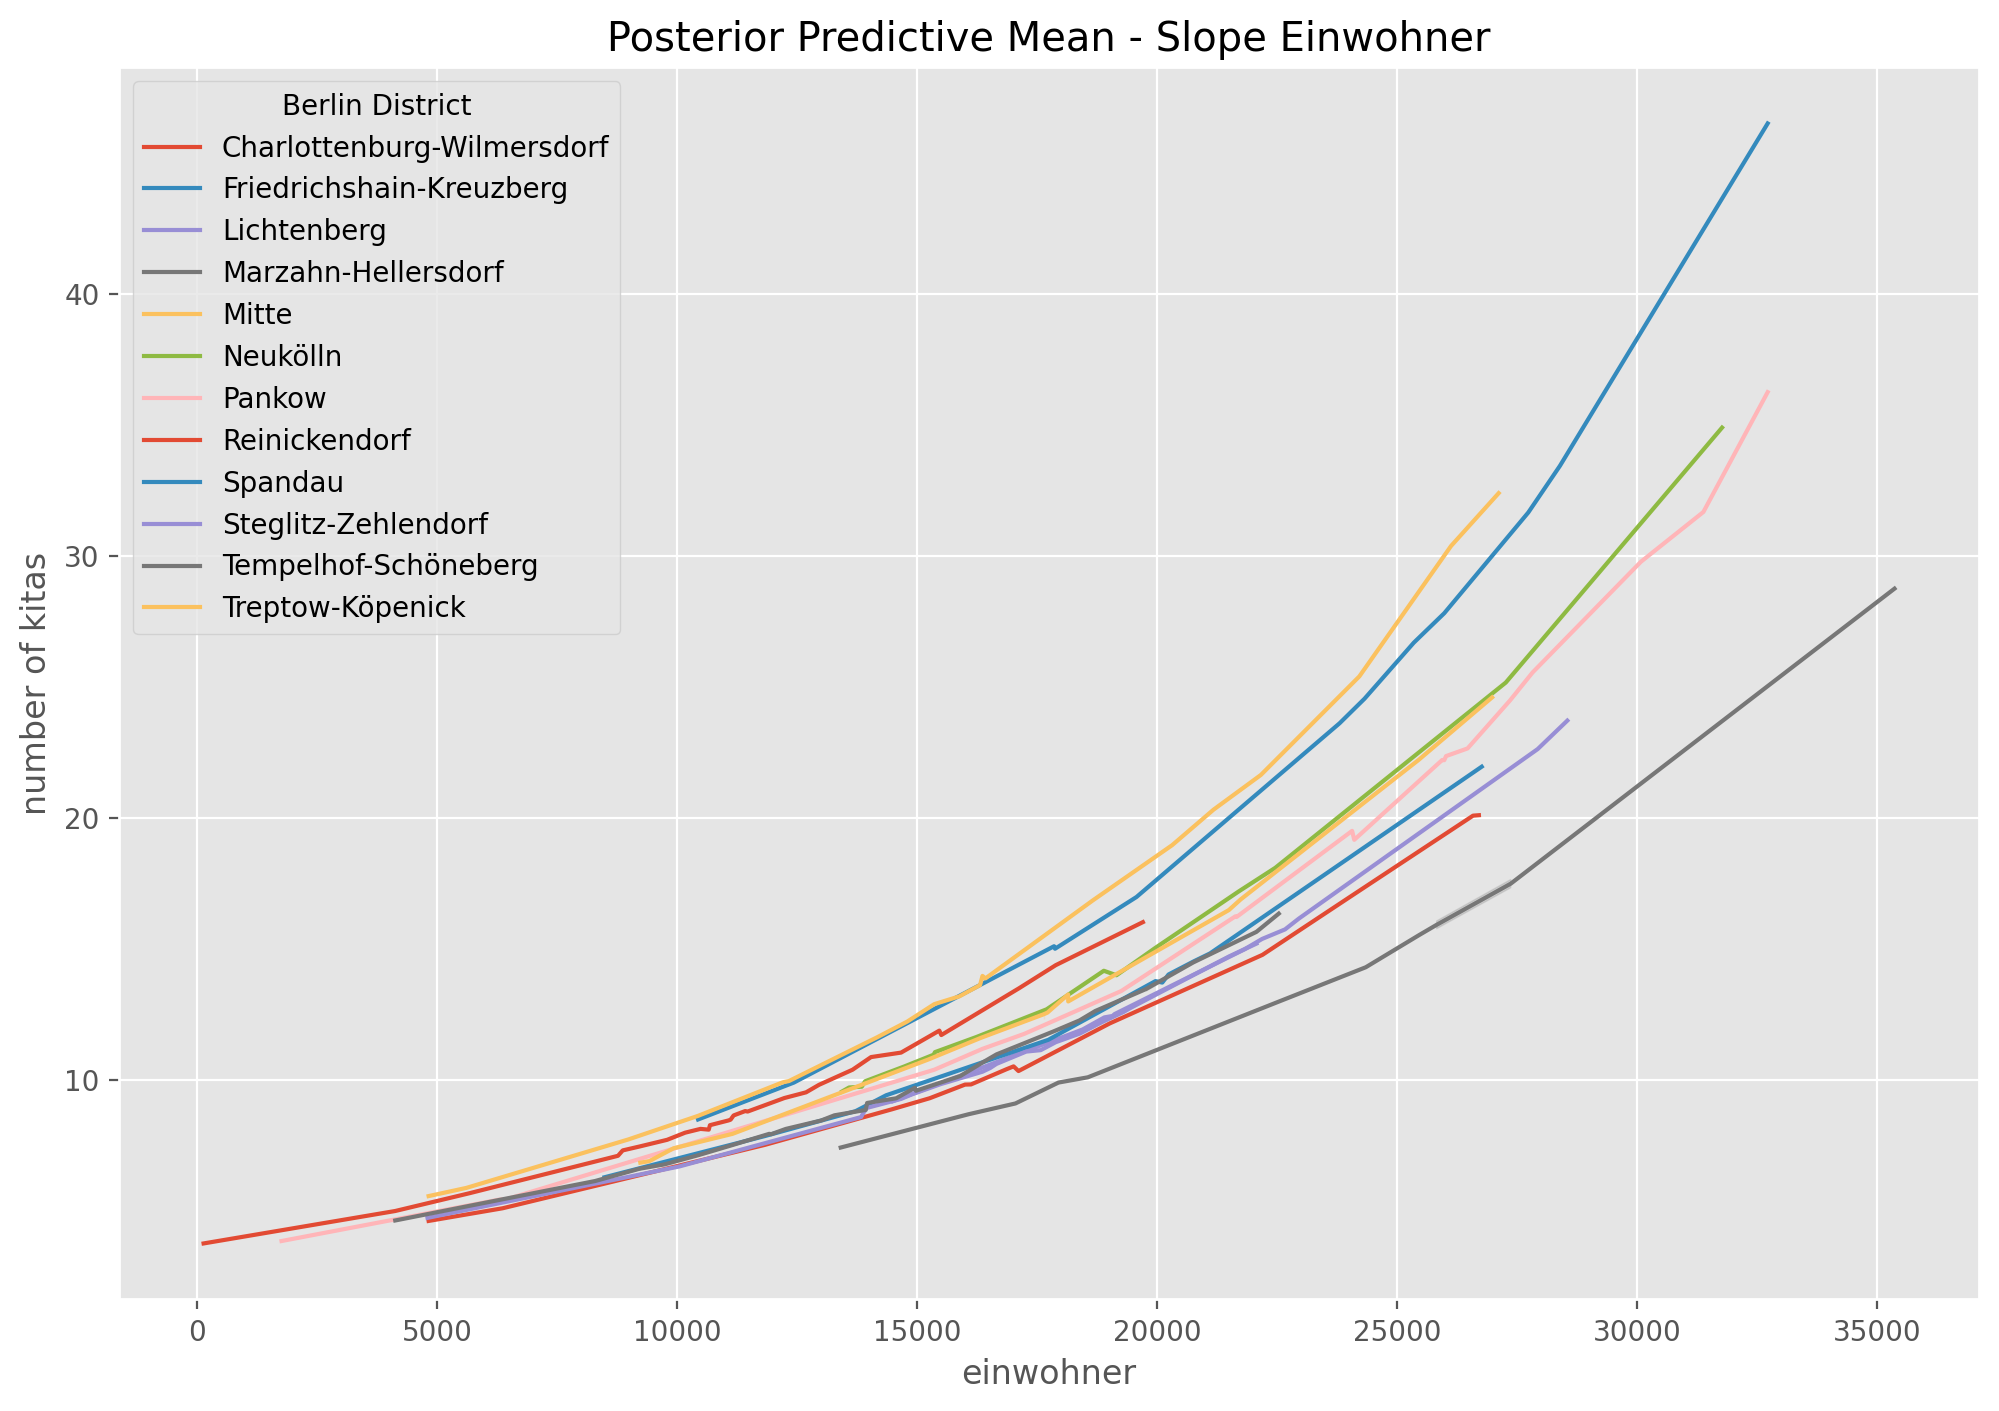

In [33]:
fig, ax = plt.subplots(figsize=(12, 8))

for i, district in enumerate(districts_encoder.classes_):
    district_df = plz_df.query("district == @district").sort_values(by="einwohner")

    sns.lineplot(
        data=district_df,
        x="einwohner",
        y="num_kitas_plz_pred_mean",
        label=district,
        ax=ax,
    )

ax.legend(title="Berlin District", loc="upper left")
ax.set(
    title="Posterior Predictive Mean - Slope Einwohner",
    xlabel="einwohner",
    ylabel="number of kitas",
)